In [6]:
!pip install shap

In [7]:
import numpy as np
import pickle

x_train = np.load("../../data/x_train_resampled.npy")
x_test = np.load("../../data/x_test.npy")

with open("../../models/fraud_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("Model Loaded Successfully")

Model Loaded Successfully


In [8]:
import shap
explainer = shap.TreeExplainer(rf_model)

print("Explainer created successfully")

Explainer created successfully


In [9]:
import numpy as np

sample_idx = np.random.choice(
    len(x_test),
    500,
    replace=False
)

x_test_sample = x_test[sample_idx]

shap_values = explainer.shap_values(x_test_sample)
print("SHAP values generated successfully")

SHAP values generated successfully


AssertionError: Feature and SHAP matrices must have the same number of rows!

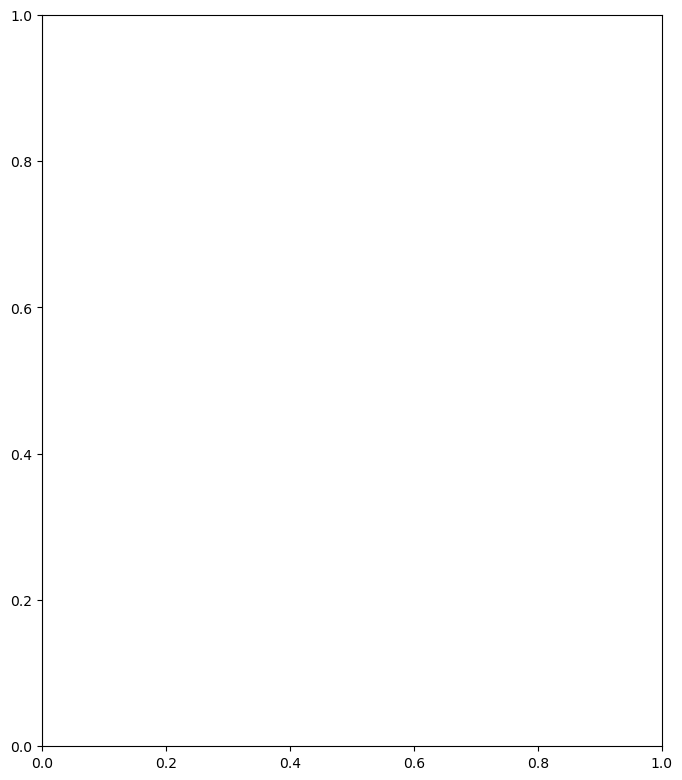

In [10]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values[:,:,1],
    x_test,
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
shap.summary_plot(
    shap_values[:,:,1],
    x_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
fraud_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:,:,1][fraud_index],
        base_values=explainer.expected_value[1],
        data=x_test[fraud_index]
    )
)